In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random as rand

Testing Coded Least Square with Random Vectors
Random X Vector:  [0.04285874 0.1430511  0.16234135 0.16569457 0.1973901  0.26623145
 0.27121835 0.42143277 0.44141496 0.49969055 0.662292   0.67473852
 0.68254801 0.72717197 0.79956665 0.83283041 0.86086902 0.90913909
 0.92957374 0.95270132]
Random Y Vector:  [0.19526551 0.2993001  0.74587738 0.82140081 0.50145501 0.77142143
 0.93391587 0.27604378 0.56796283 0.3110629  0.09954556 0.73440577
 0.80604367 0.02270158 0.07077809 0.92029574 0.65089926 0.74475533
 0.16867128 0.28840348]
Random Data Linear Fit: y= -0.154900x+0.578938
Random Slope:  -0.15490000767264658
Random Intercept:  0.578938407986179
True Line: y= 6.819666x+-1.360352
True Slope:  6.8196662155327985
True Intercept:  -1.3603516754058091
Custom Least Square:
Best fit: y= 6.627415x+-1.218582
Numpy Least Square:
Best fit: y= 6.627415x+-1.218582
Max Residual:  0.8929981750397706 at point X=  0.98
Min Residual:  -1.0232009473719748 at point X=  0.37 

Every Residual:
0.642139388032

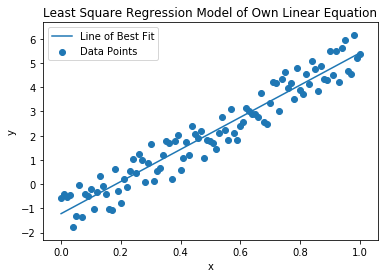

In [18]:
#My own least square apprach
def coded_least_square(X,Y):
    n=len(X)
    sum_x= np.sum(X)
    sum_y= np.sum(Y)
    sum_x2=np.sum(X**2)
    sum_xy=np.sum(X*Y)
    
    m=(n*sum_xy-sum_x*sum_y)/(n*sum_x2-(sum_x)**2)
    c=(sum_y-m*sum_x)/n
    return m,c

#Test least square regression with random points
Xrand=np.random.rand(20)
Yrand=np.random.rand(20)

idx=np.argsort(Xrand)
Xrand=Xrand[idx]
Yrand=Yrand[idx]

m_rand,c_rand=coded_least_square(Xrand,Yrand)
print("Testing Coded Least Square with Random Vectors")
print("Random X Vector: ", Xrand)
print("Random Y Vector: ", Yrand)
print(f"Random Data Linear Fit: y= {m_rand:.6f}x+{c_rand:.6f}")
print("Random Slope: ", m_rand)
print("Random Intercept: ", c_rand "\n")

# data generation 
X=np.arange(0,1.01,.01)
m_true =np.random.uniform(-10, 10)
b_true =np.random.uniform(-2,2)
error= np.random.uniform(0,1,size=(len(X)))
sign=np.random.choice([-1,1],size=len(X))
random_error=sign*error
Y=m_true*X+b_true + random_error
print ("Range Data")
print (f"True Line: y= {m_true:.6f}x+{b_true:.6f}")
print ("True Slope: ", m_true)
print ("True Intercept: ", b_true)

#custom vs numpy
m_custom, c_custom= coded_least_square(X,Y)
#numpy linear square
A=np.vstack([X,np.ones(len(X))]).T
m_numpy, c_numpy= np.linalg.lstsq(A,Y, rcond=None)[0]
print("Custom Least Square:")
print(f"Best fit: y= {m_custom:.6f}x+{c_custom:.6f}")
print("Numpy Least Square:")
print(f"Best fit: y= {m_numpy:.6f}x+{c_numpy:.6f}")
      
      
#Residuals
residuals= Y-(m_custom*X+c_custom)
max_residual= np.argmax(residuals) #when is says largest or smallest does that mean abs?
min_residual= np.argmin(residuals)
print ("Max Residual: ", residuals[max_residual], "at point X= ", X[max_residual])
print ("Min Residual: ", residuals[min_residual], "at point X= ", X[min_residual],"\n")

#print all residuals
print("Every Residual:")
for i in range (len(residuals)):
    print(residuals[i])
    
#Plotting 
plt.title("Least Square Regression Model of Own Linear Equation")
plt.xlabel("x")
plt.ylabel("y")
plt.plot(X,m_custom*X+ c_custom, label='Line of Best Fit')
plt.scatter(X, Y,label='Data Points')
plt.legend()
plt.show()